# Supervisor

This notebooks covers basic understanding of **Supervisor** pattern

The idea behind this pattern is that there exists a **Supervisor** in the runtime who is responsible for agents routing. **Supervisor** receives query, analyze and decides who to delegate the task to. Key feature is that the user does not interact with workers directly, all the interactions goes through the **Supervisor**

In [1]:
from langchain_groq.chat_models import ChatGroq
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv
import os
from pydantic import BaseModel, Field, SecretStr
from typing import TypedDict, Annotated, Literal
import operator

In [2]:
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")
if api_key:
    GROQ_API_KEY = SecretStr(api_key)

In [3]:
base_llm = ChatGroq(model="llama-3.1-8b-instant", api_key=GROQ_API_KEY)

**Business take**:

We are developing a system for story writing. Beforehand we know that our system will write 2 types of stories: sad and happy. Instead of a single agent responsible for both sad stories and happy stories we would follow Separation of Concerns principle by implementing **Supervisor** pattern.

So for the system we need the following:
1. Agent for good stories
2. Agent for sad stories
3. Supervisor for routing

In [4]:
supervisor_prompt =ChatPromptTemplate.from_template("""You are the supervisor in tell-a-story mini app.
You work with two agents: sad_story_agent, happy_story_agent. Your goal is to identify which kind of a story a user wwants to generate
and route to the correct agent.
You are to analyze user query in order to understand whether user wants a story to be happy or sad.
User query: {query}
""")

In [5]:
happy_story_agent = ChatPromptTemplate.from_template("""You are the happy_story_agent, a good writer of happy stories.
Your goal is to analyze user query, identify what they want their story to be about and write a story.
User query: {query}
The stroy should be STRICTLY HAPPY
In case you struggle identifying what story should be about(user query is unclear) write about anything you decide yourelf""")

In [6]:
sad_story_agent = ChatPromptTemplate.from_template("""You are the sad_story_agent, a good writer of sad stories.
Your goal is to analyze user query, identify what they want their story to be about and write a story.
User query: {query}
The stroy should be STRICTLY SAD
In case you struggle identifying what story should be about(user query is unclear) write about anything you decide yourelf""")

In [7]:
class SupervisorResponse(BaseModel):
    choice: Literal["sad_story_agent", "happy_story_agent"] = Field(..., description="A name of the agent who to route the task to")

In [8]:
class ChatState(TypedDict):
    query: str
    messages: Annotated[list, operator.add]
    next_agent: str

In [ ]:
def supervisor_node(state: ChatState):
    query = state["query"]
    chain = supervisor_prompt | base_llm.with_structured_output(SupervisorResponse)
    response = chain.invoke({
        "query": query,
    })
    return {"next_agent": response.choice}

def route(state: ChatState):
    messages = state["messages"]
    if messages:
        return "END"
    next_agent = state["next_agent"]
    return next_agent


In [10]:
def sad_story(state:ChatState):
    query = state["query"]
    chain = sad_story_agent | base_llm
    response = chain.invoke({
        "query": query,
    })
    return {"messages": [response]}

In [11]:
def happy_story(state:ChatState):
    query = state["query"]
    chain = happy_story_agent | base_llm
    response = chain.invoke({
        "query": query,
    })
    return {"messages": [response]}

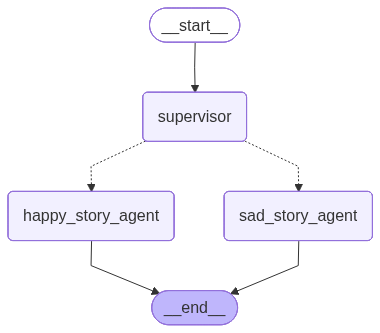

In [21]:
graph = StateGraph(ChatState)
graph.add_node("supervisor", supervisor_node)
graph.add_node("sad_story_agent", sad_story)
graph.add_node("happy_story_agent", happy_story)
graph.set_entry_point("supervisor")
graph.add_conditional_edges(
    source="supervisor",
    path=route,
    path_map={
        "sad_story_agent": "sad_story_agent",
        "happy_story_agent": "happy_story_agent",
    }
)
graph.add_edge("sad_story_agent", END)
graph.add_edge("happy_story_agent", END)
app = graph.compile()
app

In [22]:
response = app.invoke({
    "query": "Write a happy story about an office worker Paul who was resently promoted"
})

In [ ]:
response["messages"][-1].pretty_print()

================================== Ai Message ==================================

Congratulations to Paul on his recent promotion. Let me write a happy story that celebrates his achievement.

**The Sunshine Desk**

Paul walked into the office, his footsteps light and his smile beaming. The morning sunlight streaming through the windows highlighted the sparkle in his eyes. His colleagues, a talented and friendly bunch, couldn't help but notice the change in him. He had just been promoted to team lead, and the news was still fresh.

As he made his way to his new desk, a sleek and spacious corner spot with a stunning view of the city, his colleagues began to congratulate him. Handshakes, hugs, and high-fives filled the air. Paul's face glowed with happiness as he took in the warm welcome.

His new desk, lovingly referred to as the "Sunshine Desk," was a treasure trove of happy memories waiting to be made. Paul had been eyeing this spot for months, and now it was all his. He settled in, fe

In [23]:
with open(file="../story.md", mode="w", encoding="utf-8") as f:
    f.write(response["messages"][-1].content)